
# Tesla ML Pipeline — End-to-End Machine Learning on Deliveries & Production Data (2015–2025)

## Project Overview

This notebook implements a production-grade, end-to-end Machine Learning pipeline using Tesla EV Deliveries & Production Data (2015–2025).

The project demonstrates:

- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Leakage Detection & Prevention
- Pipeline-based ML Modeling
- Chronological Validation
- Hyperparameter Tuning
- Time Series Forecasting
- Forecast Evaluation

---

## Dataset

Dataset Source:
https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

Dataset contains:
- Tesla Deliveries
- Production Units
- Battery Capacity
- Vehicle Range
- CO₂ Savings
- Charging Stations
- Regional Data
- Tesla Model Information


In [1]:

# STEP 1 — Import Libraries

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA



# STEP 2 — Upload Dataset

Upload:

`tesla_deliveries_dataset_2015_2025.csv`


In [2]:

from google.colab import files

uploaded = files.upload()


Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [3]:

# STEP 3 — Load Dataset

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



# STEP 4 — Dataset Information


In [4]:

print(df.info())

print("\nMissing Values:\n")

print(df.isnull().sum())

print("\nStatistical Summary:\n")

print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:

Year                    0
Month                   0
Region                  0
Model         


# STEP 5 — Data Cleaning & Preprocessing

This step includes:
- Duplicate removal
- Date parsing
- Sorting chronologically


In [5]:

# Remove duplicates

df.drop_duplicates(inplace=True)

# Create Date column

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

# Sort chronologically

df = df.sort_values('Date').reset_index(drop=True)

print("Data Cleaning Completed")


Data Cleaning Completed



# STEP 6 — Outlier Handling using IQR Clipping

Outliers are clipped instead of removed to preserve all observations.


In [6]:

numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

print("Outlier Handling Completed")


Outlier Handling Completed



# STEP 7 — Exploratory Data Analysis (EDA)


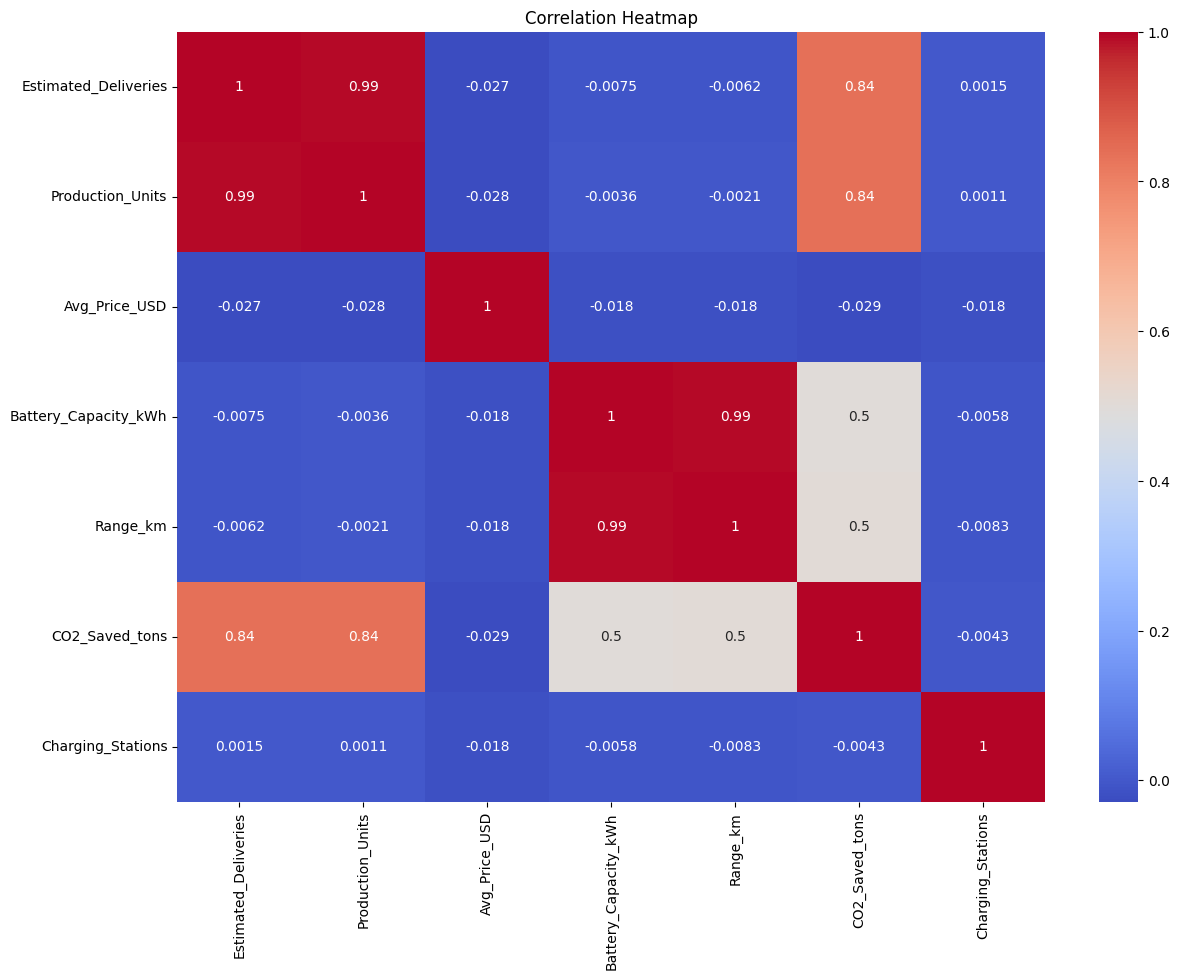

In [7]:

# Correlation Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


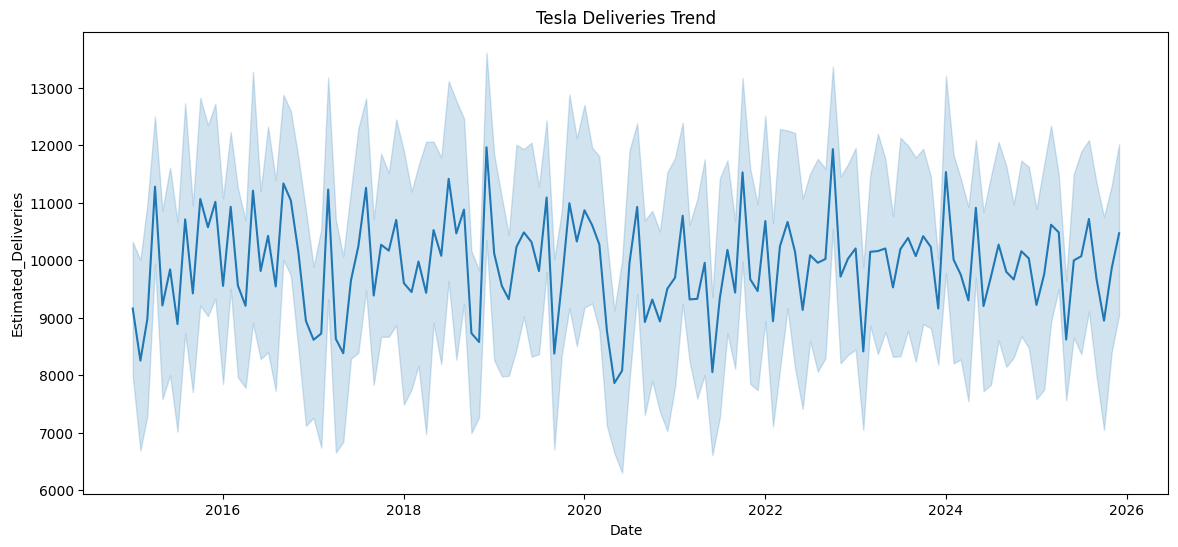

In [8]:

# Deliveries Trend

plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries Trend")

plt.show()


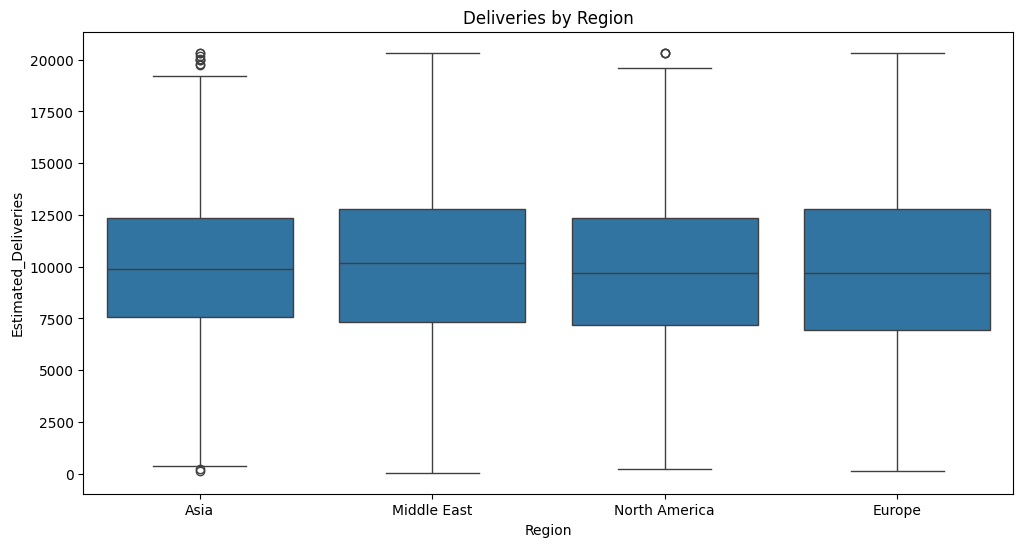

In [9]:

# Deliveries by Region

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Deliveries by Region")

plt.show()


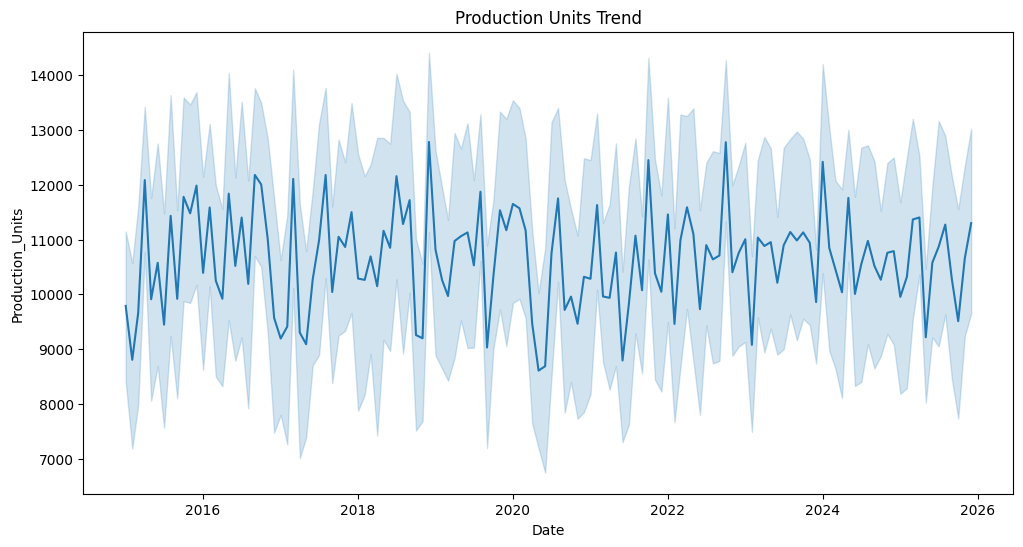

In [10]:

# Production Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Production_Units',
    data=df
)

plt.title("Production Units Trend")

plt.show()



# STEP 8 — Time Series Analysis


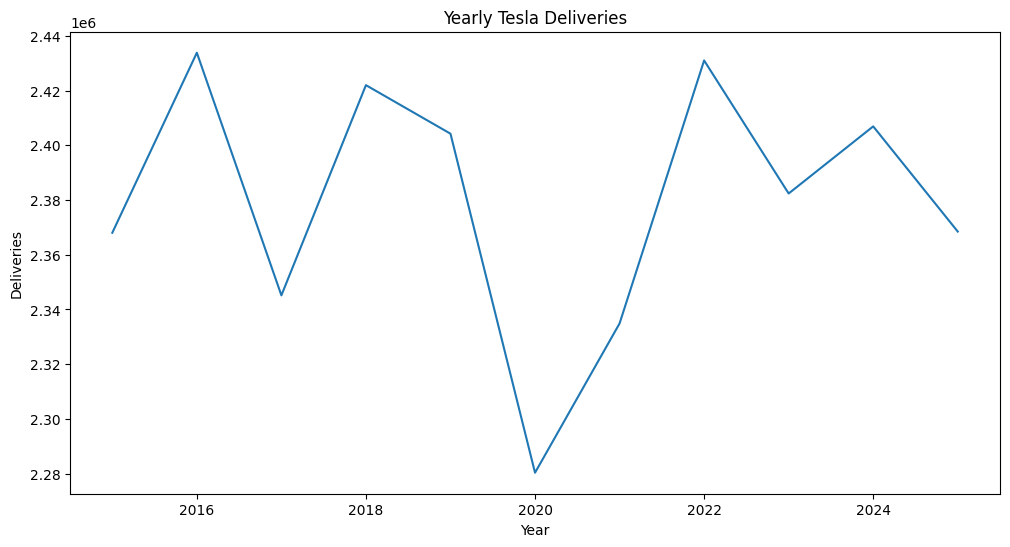

In [11]:

# Create yearly aggregated time series

ts = df.groupby('Year')[
    'Estimated_Deliveries'
].sum()

ts.plot(figsize=(12,6))

plt.title("Yearly Tesla Deliveries")

plt.ylabel("Deliveries")

plt.show()


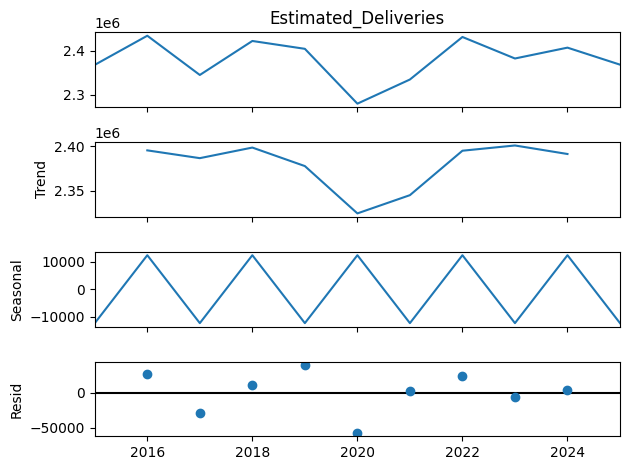

In [12]:

# Seasonal Decomposition

decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=2
)

decomposition.plot()

plt.show()


In [13]:

# ADF Stationarity Test

adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")


ADF Statistic: -5.263038437103513
p-value: 6.528250463257863e-06
Series is Stationary


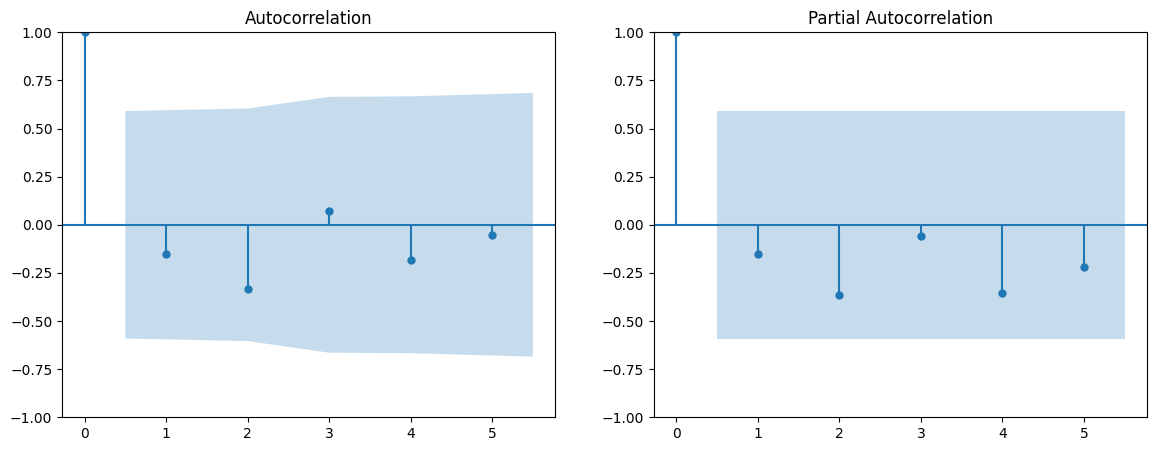

In [14]:

# ACF & PACF

fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(ts, ax=ax[0])

plot_pacf(ts, ax=ax[1])

plt.show()



# STEP 9 — Feature Engineering

This section creates:
- Lag Features
- Rolling Statistics
- Production Lag


In [15]:

# Lag Features

df['lag_1'] = df['Estimated_Deliveries'].shift(1)

df['lag_3'] = df['Estimated_Deliveries'].shift(3)

df['lag_12'] = df['Estimated_Deliveries'].shift(12)

# Rolling Mean

df['rolling_mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['rolling_mean_6'] = (
    df['Estimated_Deliveries']
    .rolling(window=6)
    .mean()
)

# Rolling Std

df['rolling_std_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .std()
)

# Production Lag

df['production_lag_1'] = (
    df['Production_Units'].shift(1)
)

# Drop NaNs generated by lagging

df.dropna(inplace=True)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,lag_1,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,production_lag_1
12,2015,1,Asia,Cybertruck,11325.0,11887.0,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01,7292.0,4350.0,12446.0,8913.000000,8228.000000,2129.679084,7298.0
13,2015,1,Asia,Model S,9537.0,10093.0,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01,11325.0,8122.0,11446.0,9384.666667,8345.333333,2020.810811,11887.0
14,2015,1,Middle East,Model S,13902.0,15423.0,94629.02,75,445,927.96,Official (Quarter),8666,2015-01-01,9537.0,7292.0,8803.0,11588.000000,9088.000000,2194.352524,10093.0
15,2015,1,Middle East,Model X,7419.0,8000.0,79927.87,75,413,459.61,Official (Quarter),4294,2015-01-01,13902.0,11325.0,6367.0,10286.000000,9599.500000,3305.763603,15423.0
16,2015,1,Europe,Model 3,7597.0,8376.0,80810.67,75,417,475.19,Interpolated (Month),8942,2015-01-01,7419.0,9537.0,8795.0,9639.333333,9512.000000,3692.650313,8000.0



# STEP 10 — Leakage Demonstration

Using current-period Production_Units directly causes target leakage.


In [16]:

print("Correlation between Production_Units and Estimated_Deliveries:\n")

corr = df['Production_Units'].corr(
    df['Estimated_Deliveries']
)

print(round(corr, 4))

print("\nVery high correlation indicates possible leakage.")


Correlation between Production_Units and Estimated_Deliveries:

0.9943

Very high correlation indicates possible leakage.



# STEP 11 — Train/Test Split (Chronological)

Chronological splitting prevents future data leakage.


In [17]:

target = 'Estimated_Deliveries'

drop_cols = [
    'Estimated_Deliveries',
    'Date',
    'Production_Units'
]

X = df.drop(columns=drop_cols)

y = df[target]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)


Training Shape: (2102, 17)
Testing Shape: (526, 17)



# STEP 12 — Pipeline Architecture

All preprocessing is wrapped inside sklearn Pipeline to prevent leakage.


In [18]:

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include='object'
).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])



# STEP 13 — Model Training


In [19]:

models = {

    'Linear Regression': LinearRegression(),

    'Ridge Regression': Ridge(),

    'Lasso Regression': Lasso(),

    'Random Forest': RandomForestRegressor(
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    mae = mean_absolute_error(y_test, preds)

    results.append([name, rmse, mae])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'RMSE', 'MAE']
)

results_df.sort_values('RMSE')


,Model,RMSE,MAE
3,Random Forest,228.064735,132.951212
4,Gradient Boosting,254.486381,175.733807
2,Lasso Regression,817.474834,597.255034
0,Linear Regression,818.623992,598.395364
1,Ridge Regression,819.311875,599.426248



# STEP 14 — TimeSeries Cross Validation


In [20]:

tscv = TimeSeriesSplit(n_splits=5)

print(tscv)


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)



# STEP 15 — Hyperparameter Tuning


In [21]:

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Params:")

print(ridge_grid.best_params_)


Best Ridge Params:
{'model__alpha': 1}


In [22]:

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

lasso_params = {
    'model__alpha': [0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Params:")

print(lasso_grid.best_params_)


Best Lasso Params:
{'model__alpha': 1}



# STEP 16 — ARIMA Forecasting


In [23]:

train_ts = ts.iloc[:-2]

test_ts = ts.iloc[-2:]

model = ARIMA(
    train_ts,
    order=(2,0,1)
)

model_fit = model.fit()

forecast = model_fit.forecast(
    steps=len(test_ts)
)

print("Forecast Values:\n")

print(forecast)


Forecast Values:

9     2.347685e+06
10    2.395014e+06
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

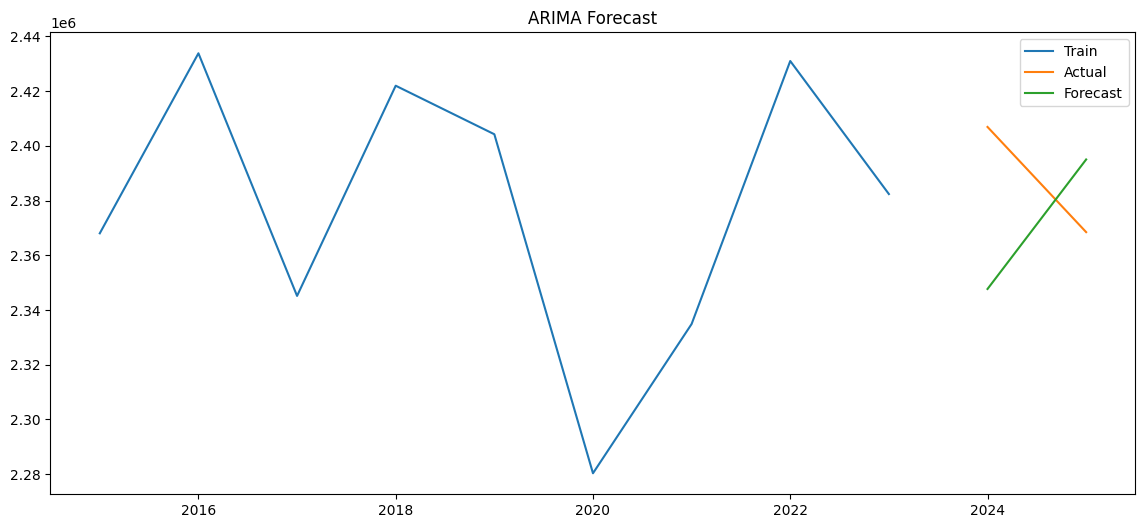

In [24]:

# Forecast Plot

plt.figure(figsize=(14,6))

plt.plot(
    train_ts.index,
    train_ts.values,
    label='Train'
)

plt.plot(
    test_ts.index,
    test_ts.values,
    label='Actual'
)

plt.plot(
    test_ts.index,
    forecast,
    label='Forecast'
)

plt.title("ARIMA Forecast")

plt.legend()

plt.show()



# STEP 17 — Final Results


In [25]:

print(results_df.sort_values('RMSE'))


               Model        RMSE         MAE
3      Random Forest  228.064735  132.951212
4  Gradient Boosting  254.486381  175.733807
2   Lasso Regression  817.474834  597.255034
0  Linear Regression  818.623992  598.395364
1   Ridge Regression  819.311875  599.426248



# STEP 18 — Final Conclusion

## Key Learnings

- Proper time-series validation is essential.
- Pipelines prevent preprocessing leakage.
- Lag features improve forecasting realism.
- Extremely high R² may indicate leakage.
- Chronological validation provides honest evaluation.

---

## Final Summary

This project successfully implemented a production-grade Machine Learning pipeline for Tesla EV deliveries and production analytics.

The notebook demonstrated:

- Robust preprocessing
- Time-series-aware validation
- Pipeline-based architecture
- Leakage prevention
- Forecasting methodology
- Model comparison
- Hyperparameter tuning

The workflow reflects practical ML engineering practices used in real-world forecasting systems.
